# Train — ResNet-18

Trains and evaluates ResNet-18 using the tuned hyperparameters from `ARCH_HYPERPARAMS["resnet18"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1707 | Val: 415 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["resnet18"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"ResNet-18: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders, same as every other architecture
# here -- its own (capped) batch size and image size, per cfg.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

ResNet-18: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model (Transfer Learning with ResNet-18)

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with ResNet-18)
# ---------------------------------------------------------
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the tuned step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[ResNet-18] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[ResNet-18] Epoch   1/100 | LR: 3.88e-04 | train loss 0.9522 acc 0.556 | val loss 0.6146 acc 0.733 *


[ResNet-18] Epoch   2/100 | LR: 3.88e-04 | train loss 0.7274 acc 0.678 | val loss 0.7072 acc 0.730


[ResNet-18] Epoch   3/100 | LR: 3.88e-04 | train loss 0.6211 acc 0.725 | val loss 0.7391 acc 0.689


[ResNet-18] Epoch   4/100 | LR: 3.88e-04 | train loss 0.5158 acc 0.746 | val loss 0.6363 acc 0.783


...

[ResNet-18] Epoch  15/100 | LR: 3.88e-05 | train loss 0.2022 acc 0.899 | val loss 0.4636 acc 0.841


[ResNet-18] Epoch  16/100 | LR: 3.88e-05 | train loss 0.2047 acc 0.898 | val loss 0.4618 acc 0.848


[ResNet-18] Epoch  17/100 | LR: 3.88e-05 | train loss 0.1801 acc 0.914 | val loss 0.4448 acc 0.846


[ResNet-18] Epoch  18/100 | LR: 3.88e-05 | train loss 0.1670 acc 0.914 | val loss 0.4579 acc 0.843


[ResNet-18] Epoch  19/100 | LR: 3.88e-05 | train loss 0.1784 acc 0.913 | val loss 0.4500 acc 0.836

[ResNet-18] No val loss improvement for 10 epochs — stopping early at epoch 19.

[ResNet-18] Restored best checkpoint (val loss = 0.4398)


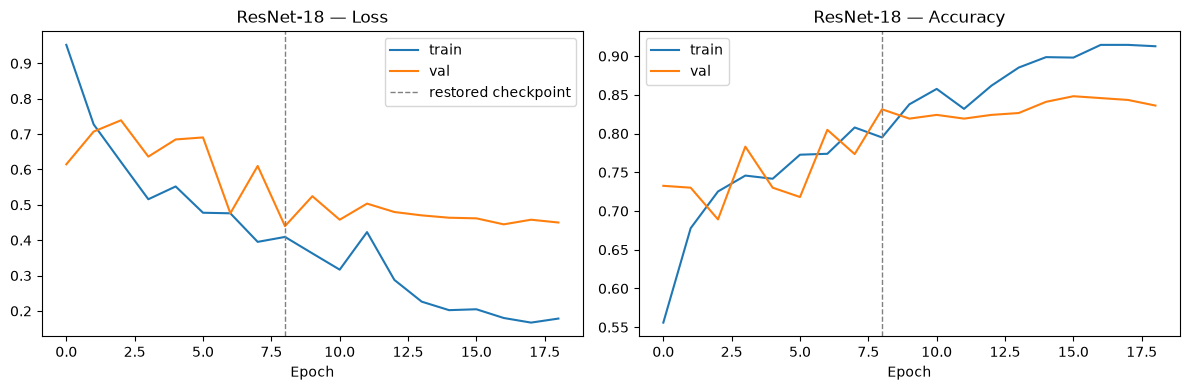

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "ResNet-18", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "ResNet-18")

## Evaluate on the test set

[ResNet-18] Test accuracy: 0.840


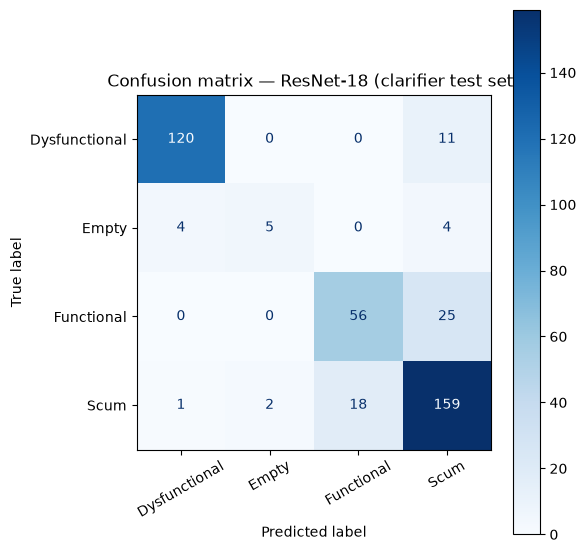

               precision    recall  f1-score   support

Dysfunctional      0.960     0.916     0.938       131
        Empty      0.714     0.385     0.500        13
   Functional      0.757     0.691     0.723        81
         Scum      0.799     0.883     0.839       180

     accuracy                          0.840       405
    macro avg      0.808     0.719     0.750       405
 weighted avg      0.840     0.840     0.837       405



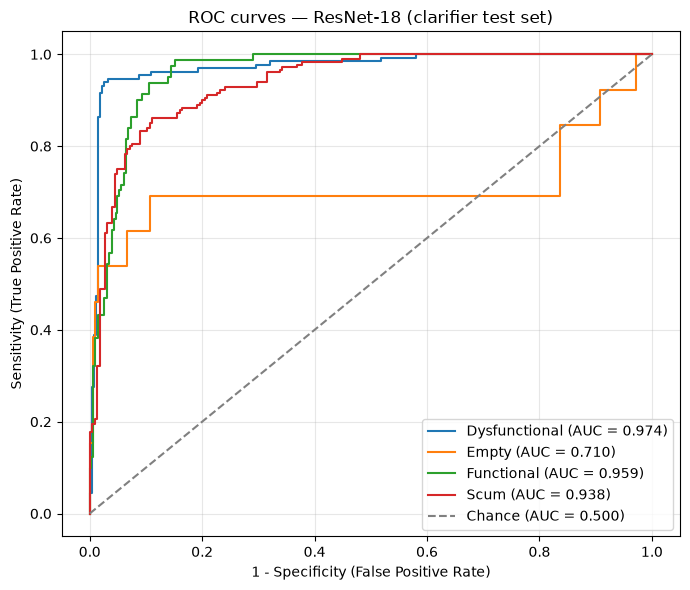

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.974
  Empty          : 0.710
  Functional     : 0.959
  Scum           : 0.938

Mean AUC (over 4/4 classes with test examples): 0.895


(np.float64(0.8395061728395061),
 {'Dysfunctional': 0.9738953585557475,
  'Empty': 0.7101648351648352,
  'Functional': 0.9591525682060662,
  'Scum': 0.9381481481481482})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "ResNet-18", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

This is the step the results notebook depends on — it pickles the metrics/history and saves the model state dict so nothing needs to be kept in memory or re-trained.

In [6]:
save_result("ResNet-18", "resnet18")

Saved results to ../results/clarifier_aug/results_clarifier_resnet18_NoordelikeWerke.pkl


Saved model weights to ../models/clarifier_resnet18_cnn.pt
